In [54]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter,zoom
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion,binary_dilation
from scipy.stats import norm
from sklearn.mixture import GaussianMixture
import pickle
import warnings
from scipy import signal

In [5]:
def supervoxel_to_full_res(brain, cluster_labels):
    n_clusters = brain.shape[2]
    n_tp = brain.shape[1]
    brain_dims=[314,146]
    
    reformed_brain = []
    for z in range(brain.shape[0]):
        colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]))
        for cluster_num in range(n_clusters):
            cluster_mask = cluster_labels[z,:]==cluster_num
#             print(cluster_indicies)
            colored_by_betas[:,cluster_mask] = brain[z,:,cluster_num,np.newaxis]
        colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1])
        reformed_brain.append(colored_by_betas)
    return np.asarray(reformed_brain)


In [6]:
### big STA supervox
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')

behaviors = ['total', 'inc', 'dec', 'flat']

n_clusters=2000

step_size=100
event='10flies'
ch=2
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [10]:
behave_dict_1 = {}
behave_dict_2 = {}

for behavior in behaviors:
    behave_dir = os.path.join(later_dir, behavior)
#     print(behave_dir)
    behave_dict_1[behavior]=[]
    behave_dict_2[behavior]=[]
    for file in os.listdir(behave_dir):
        if 'STA' in file and str(step_size) in file and event in file:
            STA_path=os.path.join(behave_dir, file)
            print(STA_path)
            with h5py.File(STA_path, 'r') as sf:
                brain = sf['data'][:]
                brain[np.isnan(brain)] = 0
                brain[np.isinf(brain)] = 4
                brain = np.moveaxis(brain, 0, -1)
                dims=np.shape(brain)
                print(f'brain shape: {dims}')
                if '_2_' in file:
                    behave_dict_2[behavior]=brain
                if '_1_' in file:
                    behave_dict_1[behavior]=brain

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/total/STA_1_total_100_10flies.h5
brain shape: (314, 146, 91, 24)
/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/total/STA_2_total_100_10flies.h5
brain shape: (314, 146, 91, 24)
/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/inc/STA_2_inc_100_10flies.h5
brain shape: (314, 146, 91, 24)
/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/inc/STA_1_inc_100_10flies.h5
brain shape: (314, 146, 91, 24)
/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/dec/STA_1_dec_100_10flies.h5
brain shape: (314, 146, 91, 24)
/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/dec/STA_2_dec_100_10flies.h5
brain shape: (314, 146, 91, 24)
/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/flat/STA_1_flat_100_10flies.h5
brain shape: (314, 146, 91, 24)
/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/flat/STA_2_flat_100_10flies.h5
brain shape: (314, 146, 91, 24)


In [12]:
behave_dict_2.keys()

dict_keys(['total', 'inc', 'dec', 'flat'])

In [13]:
giant_cluster_labels = np.load(os.path.join(cluster_dir, 'cluster_labels_best_flies.npy'))

In [15]:
def make_supervox_fullres_dicts(behave_dict, labels, n_clusters):
    supervox_dict={}
    full_res={}
    behaviors=list(behave_dict.keys())
    for behave in behaviors:
        supervox_dict[behave]=[]
        brain = behave_dict[behave]
        dims = np.shape(brain)
    #     supervox_dict[behave]['signals']=[]
        for z in range(dims[-2]):
            neural_activity = brain[:,:,z,:].reshape(-1, dims[3])
    #         print(np.shape(neural_activity))
            signals = []
            for cluster_num in range(n_clusters):
                cluster_indicies = np.where(labels[z,:]==cluster_num)[0]
                mean_signal = np.mean(neural_activity[cluster_indicies,:], axis=0)
                signals.append(mean_signal)
            signals = np.asarray(signals)
            supervox_dict[behave].append(signals)
        supervox_dict[behave] = np.asarray(supervox_dict[behave])
        print(np.shape(supervox_dict[behave]))
    
    for behave in behaviors:
        supervox_brain=np.moveaxis(supervox_dict[behave],-1,-2)
        full_res_brain=supervoxel_to_full_res(supervox_brain, labels)
        full_res_brain=np.moveaxis(full_res_brain, 0,-1)
        print(np.shape(full_res_brain))
        full_res[behave]=np.asarray(full_res_brain)
    return supervox_dict, full_res

In [17]:
%%time
supervox_dict_1, full_res_1=make_supervox_fullres_dicts(behave_dict_1, giant_cluster_labels, n_clusters)
supervox_dict_2, full_res_2=make_supervox_fullres_dicts(behave_dict_2, giant_cluster_labels, n_clusters)

(91, 2000, 24)
(91, 2000, 24)
(91, 2000, 24)
(91, 2000, 24)
(24, 314, 146, 91)
(24, 314, 146, 91)
(24, 314, 146, 91)
(24, 314, 146, 91)
(91, 2000, 24)
(91, 2000, 24)
(91, 2000, 24)
(91, 2000, 24)
(24, 314, 146, 91)
(24, 314, 146, 91)
(24, 314, 146, 91)
(24, 314, 146, 91)
CPU times: user 2min 25s, sys: 3.24 s, total: 2min 28s
Wall time: 2min 28s


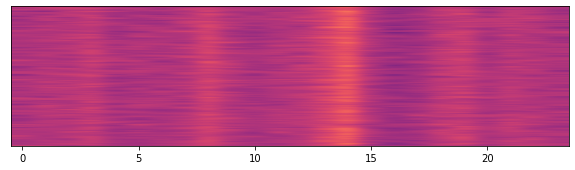

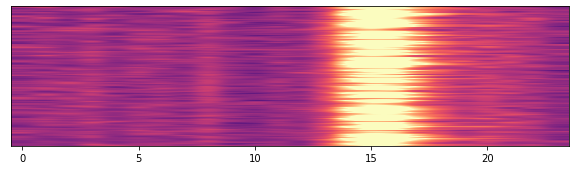

In [19]:
be='total'

fig,axs = plt.subplots(figsize=(10,10))
axs.imshow(supervox_dict_1[be][50],cmap='magma',vmax=0.01, vmin=-0.01, interpolation='gaussian')
axs.set_yticks([])
axs.set_aspect(0.003)

fig,axs = plt.subplots(figsize=(10,10))
axs.imshow(supervox_dict_2[be][50],cmap='magma',vmax=0.01, vmin=-0.01, interpolation='gaussian')
axs.set_yticks([])
axs.set_aspect(0.003)

In [27]:
supervox_dict_1[be].shape

(91, 2000, 24)

In [85]:
%%time
z,xy,t=np.shape(supervox_dict_1[be])
flat_red=supervox_dict_1[be].reshape(xy*z,t)
flat_green=supervox_dict_2[be].reshape(xy*z,t)
# # 5. Normalize both x and y data to improve numerical stability
# x_mean, x_std = np.mean(flat_red), np.std(flat_red)
# y_mean, y_std = np.mean(flat_green), np.std(flat_green)

# # Avoid division by zero
# if x_std == 0:
#     x_std = 1.0
# if y_std == 0:
#     y_std = 1.0
# x_normalized = (flat_red - x_mean) / x_std
# y_normalized = (flat_green - y_mean) / y_std
print(flat_green.shape)
flat_sig=np.zeros_like(flat_green)
for i in range(np.shape(flat_red)[0]):
    a=np.polyfit(flat_red[i,:],flat_green[i,:],1)
    sig = flat_green[i,:] - (a[0]*flat_red[i,:] + a[1])
    flat_sig[i,:]=sig
supervox_sig=flat_sig.reshape(z,xy,t)

(182000, 24)
CPU times: user 13.2 s, sys: 273 ms, total: 13.5 s
Wall time: 13 s


In [86]:
supervox_sig.shape

(91, 2000, 24)

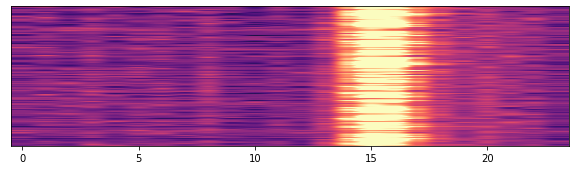

In [51]:
fig,axs = plt.subplots(figsize=(10,10))
axs.imshow(supervox_sig[50], vmax=0.01, vmin=-0.01,cmap='magma')
axs.set_yticks([])
axs.set_aspect(0.003)

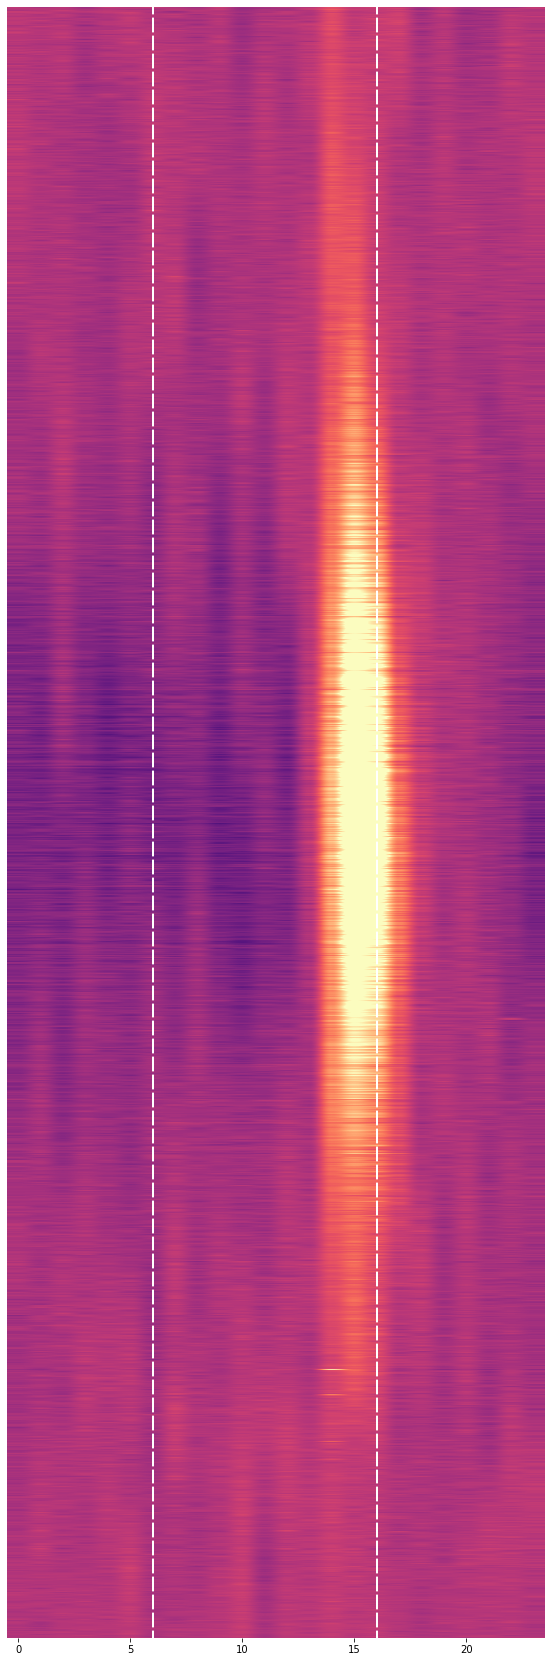

In [52]:
# data=gaussian_filter(supervox_dict[be], sigma=1)
data=supervox_sig
vmax=0.01
vmin=-0.01
# norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
# final = norm(data)
# mycmap = matplotlib.cm.get_cmap('magma')
# final = mycmap(final)
num_areas=np.shape(data)[0]
fig = plt.figure(figsize=(10,30))
gs = fig.add_gridspec(nrows=num_areas, ncols=1, hspace=0)
axs = gs.subplots(sharex='col', sharey=False)
for i in range(num_areas):
    img=axs[i].imshow(data[i], cmap='magma', vmax=vmax, vmin=vmin)
    axs[i].set_yticks([])
    #     axs[i].set_xticks([])
    axs[i].set_aspect(0.0004)
    axs[i].axvline(x=6, ymin=0, ymax=1, ls='--', color='w', lw=2)
    axs[i].axvline(x=16, ymin=0, ymax=1, ls='--', color='w', lw=2)
#     axs[i].set_ylabel(f'z={i}', rotation=0, labelpad=20)
for ax in axs:
    ax.label_outer()
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
# fig.colorbar(img, ax=axs)

# plt.savefig(os.path.join(save_dir,'supervox_heatmap.png'), dpi=150)
# plt.savefig(os.path.join(save_dir,'supervox_heatmap.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

plt.show()

In [87]:
sig_test=supervox_sig
# sig_test=supervox_dict['green']

fs=180
# half_wid = 5
# half_y = 500
# kernel2d = np.ones((half_wid*2, half_y*2))/(4*half_wid*half_y)
# conv_template = signal.convolve2d(np.mean(sig_test, axis=-1), kernel2d, boundary='symm', mode='valid')
# # print(np.shape(conv_template))
# test_x, test_y = np.unravel_index(np.argmin(conv_template), conv_template.shape)
# test_x += half_wid
# test_y += half_y


In [88]:
kernel2d.shape

(10, 1000)

In [92]:
# test_patch = sig_test[test_x-half_wid:test_x+half_wid, test_y-half_y:test_y+half_y, :]
test_patch = sig_test
test = test_patch.mean(axis=(0,1))
# test = test.flatten(order='F') 
# test = (test-test.mean())/test.std()

In [93]:
test.shape

(24,)

(13,)


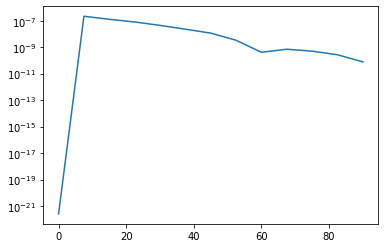

In [95]:
f, Pxx_den = signal.periodogram(test, fs)
print(np.shape(Pxx_den))
plt.semilogy(f, Pxx_den)
# plt.axvline(val, c='k')
# plt.ylim([1e-7, 1000])